## Data Preparation

In [1]:
import pandas as pd

# Load the datasets
pokemon_df = pd.read_csv('pokemon.csv')
combats_df = pd.read_csv('combats.csv')

print('Pokemon DataFrame head:')
display(pokemon_df.head())

print('\nCombats DataFrame head:')
display(combats_df.head())

Pokemon DataFrame head:


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False



Combats DataFrame head:


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


### Missing Values Management

In [2]:
# Identify Pokémon #62 (Primeape) and fill in its missing Name
# First, check if there's any missing name for pokemon #62
missing_name_pokemon_62 = pokemon_df[(pokemon_df['#'] == 62) & (pokemon_df['Name'].isnull())]

if not missing_name_pokemon_62.empty:
    pokemon_df.loc[pokemon_df['#'] == 62, 'Name'] = 'Primeape'
    print("Updated Pokémon #62's name to 'Primeape'.")
else:
    print("Pokémon #62's name is already present or was not missing.")

# Verify the update (if any)
display(pokemon_df[pokemon_df['#'] == 62])

Pokémon #62's name is already present or was not missing.


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
61,62,Mankey,Fighting,NaN,40,80,35,35,45,70,1,False


In [3]:
# Handle NaN values in 'Type 2' by replacing them with 'Aucun'
pokemon_df['Type 2'] = pokemon_df['Type 2'].fillna('Aucun')

print("Missing values in 'Type 2' after fillna:")
display(pokemon_df['Type 2'].isnull().sum())

print("First 5 rows of pokemon_df after updating 'Type 2':")
display(pokemon_df.head())

Missing values in 'Type 2' after fillna:


np.int64(0)

First 5 rows of pokemon_df after updating 'Type 2':


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,Aucun,39,52,43,60,50,65,1,False


### Calculate Win Percentage

In [4]:
# Calculate the number of fights each pokemon participated in
fights_participated = combats_df['First_pokemon'].value_counts().add(combats_df['Second_pokemon'].value_counts(), fill_value=0).astype(int)

# Calculate the number of wins for each pokemon
wins = combats_df['Winner'].value_counts()

# Create a DataFrame for win/fight counts, ensuring all pokemon are included
pokemon_stats = pd.DataFrame({
    'TotalFights': fights_participated,
    'Wins': wins
}).fillna(0)

# Calculate win percentage
pokemon_stats['WinPercentage'] = (pokemon_stats['Wins'] / pokemon_stats['TotalFights']) * 100

# Ensure pokemon_df is indexed by '#' for proper alignment
# Only set index if '#' is still a column to prevent KeyError on re-execution
if '#' in pokemon_df.columns:
    pokemon_df = pokemon_df.set_index('#')

# Remove any existing 'WinPercentage' columns (e.g., WinPercentage, WinPercentage_x, WinPercentage_y)
# before adding the new one to prevent duplicates on re-execution.
columns_to_drop = [col for col in pokemon_df.columns if col.startswith('WinPercentage')]
if columns_to_drop:
    pokemon_df = pokemon_df.drop(columns=columns_to_drop)

# Directly assign the calculated WinPercentage using the index for alignment
pokemon_df['WinPercentage'] = pokemon_stats['WinPercentage']

# Fill NaN WinPercentage for pokemon that didn't participate in fights (if any) with 0
pokemon_df['WinPercentage'] = pokemon_df['WinPercentage'].fillna(0)

print("Pokemon DataFrame with Win Percentage:")
display(pokemon_df.head())

Pokemon DataFrame with Win Percentage:


,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,WinPercentage
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,27.819549
2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,38.016529
3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,67.424242
4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,56.000000
5,Charmander,Fire,Aucun,39,52,43,60,50,65,1,False,49.107143


## Exploratory Analysis and Visualization

### Correlation Matrix

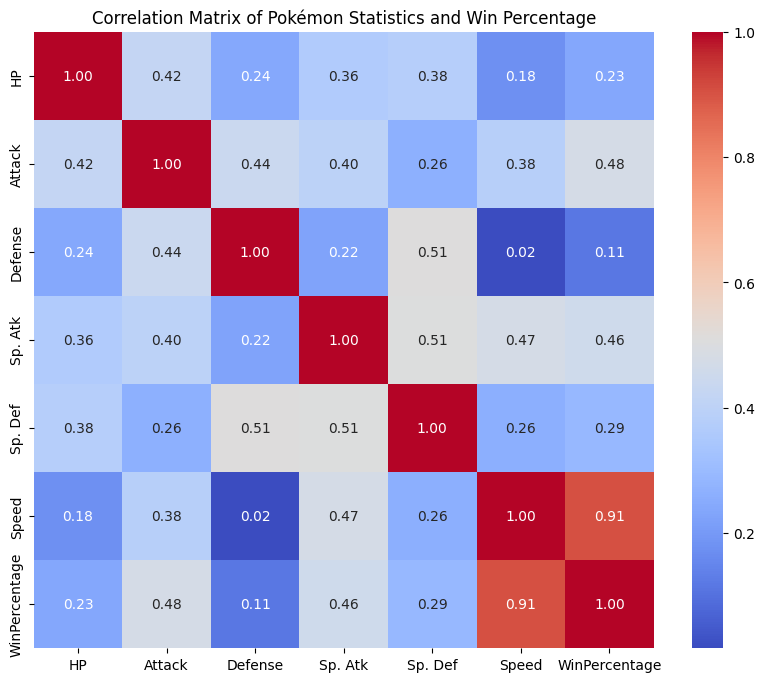

Correlation Matrix:


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,WinPercentage
HP,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.234889
Attack,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.476675
Defense,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.113312
Sp. Atk,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.455848
Sp. Def,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.291603
Speed,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,0.905409
WinPercentage,0.234889,0.476675,0.113312,0.455848,0.291603,0.905409,1.000000


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns for correlation
correlation_columns = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'WinPercentage']
correlation_matrix = pokemon_df[correlation_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Pokémon Statistics and Win Percentage')
plt.show()

print("Correlation Matrix:")
display(correlation_matrix)